# Import Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import plotly.graph_objects as go
import warnings 
warnings.filterwarnings("ignore")
sns.set_style("darkgrid")
sns.set_theme(
    style="darkgrid",
    palette="Blues"
)
print ("done")

done


# load data 

In [2]:
df = pd.read_csv("/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv")

In [3]:
df.head(6)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q


In [4]:
df.tail(7)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.050,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.125,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.450,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.750,NaN,Q


In [5]:
df.shape

(891, 12)

In [6]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Observations from df.info()

1. The dataset has 891 rows and 12 columns.
2. There are missing values in three columns:
   - 'Cabin' is missing most of its data (only 204 non-null values).
   - 'Age' is missing 177 values.
   - 'Embarked' is missing only 2 values.
3. The data types look correct (integers, floats, and objects for text).

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Observations from df.describe()

1. Around 38.3% of the passengers in this dataset survived (from the mean of 'Survived').
2. The 'Age' column has a wide range, from babies (0.42 years old) up to 80 years old, with an average age of around 29.7.
3. The 'Fare' column shows a huge jump between the 75th percentile (31) and the maximum value (512). This indicates the presence of strong outliers that we need to investigate.

In [9]:
df['Fare'].nlargest(5)

258    512.3292
679    512.3292
737    512.3292
27     263.0000
88     263.0000
Name: Fare, dtype: float64

### Observations from nlargest(5) on Fare

1. The maximum fare of 512.3292 is not an error because it appears exactly three times (rows 258, 679, and 737).
2. After these three VIP passengers, the next highest fare drops significantly to 263.
3. This confirms that 512.3292 is an extreme outlier, representing a very high-class suite on the ship.

In [10]:
df.describe(include = 'O')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,1601,G6,S
freq,1,577,7,4,644


In [11]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [12]:
data_missing = df.isnull().sum()
data_missing[data_missing > 0]

Age         177
Cabin       687
Embarked      2
dtype: int64

In [13]:
missing_percentage = (data_missing / len(df)) * 100
missing_percentage

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [14]:
df.duplicated().sum()

np.int64(0)

<div style="text-align: center; border: 1px solid #333333; padding: 20px; border-radius: 8px; background-color: #1e1e1e; color: #ffffff; max-width: 80%; margin: 0 auto;">

<h1 style="color: #4fc3f7; margin-bottom: 20px;">Data Overview Summary</h1>

<h3 style="color: #4fc3f7;">Data Structure</h3>
<p>The dataset contains 891 rows and 12 columns.</p>
<p>Most columns are numerical, except for Name, Sex, Ticket, Cabin, and Embarked.</p>

<h3 style="color: #4fc3f7;">Missing Values</h3>
<p><strong>Cabin:</strong> 687 missing values | <strong>Age:</strong> 177 missing values | <strong>Embarked:</strong> 2 missing values</p>

<h3 style="color: #4fc3f7;">Outliers</h3>
<p><strong>Fare:</strong> The maximum fare of 512.33 is much higher than the average of 32.20. This indicates potential outliers from wealthy first-class passengers.</p>
<p><strong>Age:</strong> The maximum age is 80, while the average is 29.70 and most passengers are between 20 and 38.</p>
<p><strong>SibSp & Parch:</strong> Most passengers traveled alone (median is 0), but some families have up to 8 siblings/spouses or 6 parents/children, which are rare cases.</p>

<h3 style="color: #4fc3f7;">Duplicate Rows</h3>
<p>There are no duplicate rows in the dataset.</p>

</div>

# Data Cleaning 

In [15]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [16]:
df['Embarked'] = df['Embarked'].fillna('S')
print(df['Embarked'].isnull().sum())

0


In [17]:
 df.groupby(['Pclass','Sex'])['Age'].median()

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

In [18]:
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

In [19]:
print(df['Age'].isnull().sum())

0


In [20]:
df.drop(columns=['Cabin'], inplace=True)

In [21]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


##  Data Cleaning: Handling Missing Values

In this section, we address the missing data across the dataset to ensure audit-ready and robust quality before moving to modeling.

1. **Embarked Column**: Filled the 2 missing values with the **Mode ('S')** since it is a categorical feature and 'S' is the most frequent port.
2. **Age Column**: Implemented a **Contextual/Grouped Imputation** using a custom logic (`Pclass` and `Sex`). Instead of using a global median, missing ages were filled based on the specific median of the passenger's class and gender to maintain realistic data distribution.
3. **Cabin Column**: Dropped completely because **77%** of its values were missing, and keeping it would introduce heavy noise and false data generation.

# Outlier

<Axes: >

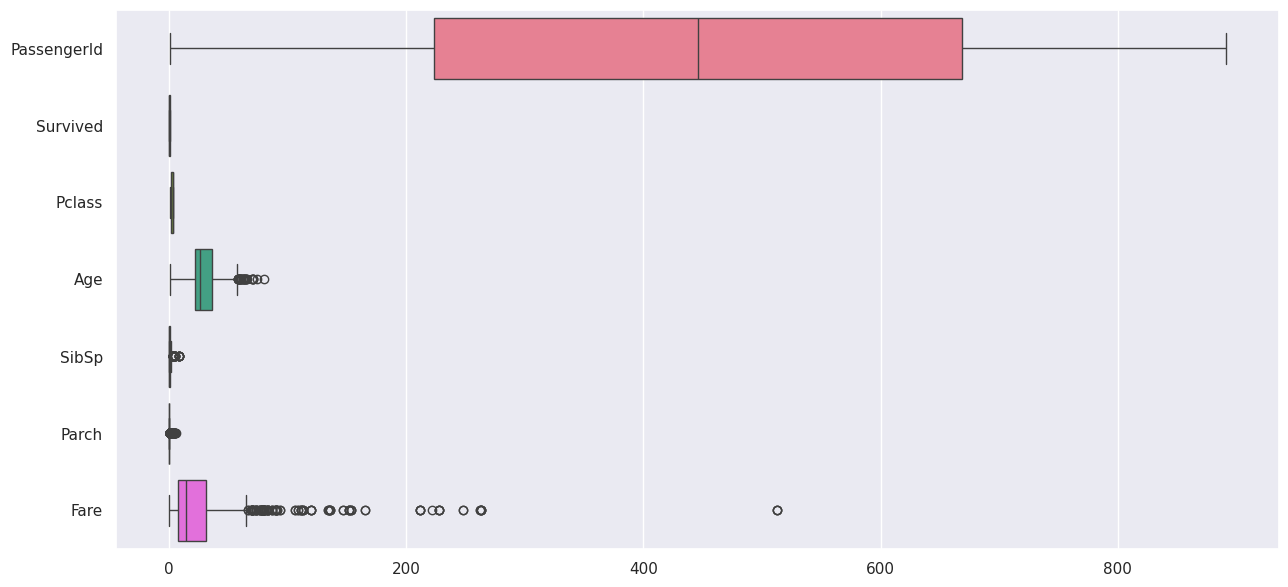

In [22]:
plt.figure(figsize=(15,7))
sns.boxplot(df,orient='h')

## Why We Didn't Modify Outliers (Data Analyst Perspective)

Before moving to the Exploratory Data Analysis (EDA), it is crucial to state our policy regarding outliers in columns like **`Fare`** (e.g., $512 tickets) and **`Age`** (e.g., 80-year-old passengers):

1. **Business Reality, Not Errors**: These extreme values are genuine business facts, not data-entry mistakes. The $512 fares represent luxury first-class suites, which are vital for understanding the financial demographics of the passengers.
2. **Preserving Critical Insights**: In a historical disaster dataset like Titanic, outliers hold the most valuable insights. Transforming them (via Log) or removing them (via Trimming) would hide the socioeconomic impact on survival rates.
3. **Strategic Decision**: We intentionally kept these outliers in their raw form to analyze them thoroughly during the **EDA phase** and see how extreme wealth or extreme age affected the chances of survival.

# EDA (Exploratory Data Analysis)

### Survival Count by Gender

In [23]:

pd.crosstab(df['Sex'], df['Survived'])

Survived,0,1
Sex,,
female,81,233
male,468,109


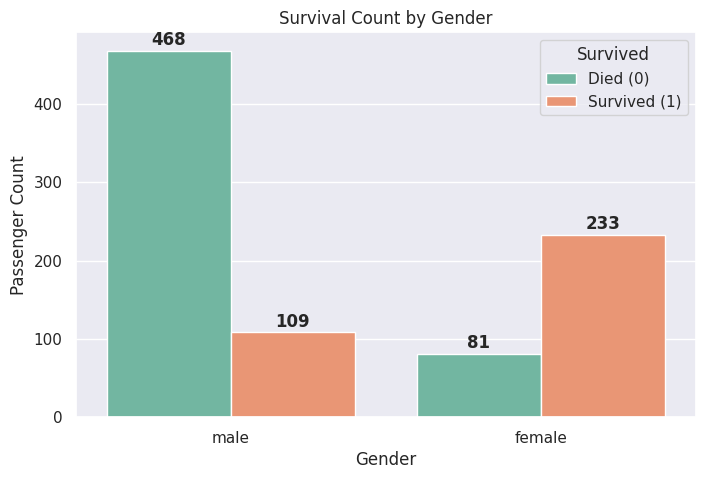

In [24]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Sex', hue='Survived', palette='Set2')
plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')
plt.legend(title='Survived', labels=['Died (0)', 'Survived (1)'])
for container in ax.containers:
    ax.bar_label(container, fontweight='bold', padding=1)
plt.show()

###  Key Insight: Gender vs. Survival

* **High Mortality Rate Among Men**: The visual hierarchy clearly shows a massive gap; the vast majority of male passengers did not survive the disaster.
* **High Survival Rate Among Women**: Conversely, the overwhelming majority of female passengers were successfully rescued and survived.
* **Historical Context**: This data perfectly reflects the strict enforcement of the maritime chivalry code **"Women and children first"** during the evacuation, where females were given absolute priority on the limited lifeboats.

### Survival Count by Passenger Class

In [25]:
# Did the ticket class and social status affect the chances of survival?
pd.crosstab(df['Pclass'], df['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


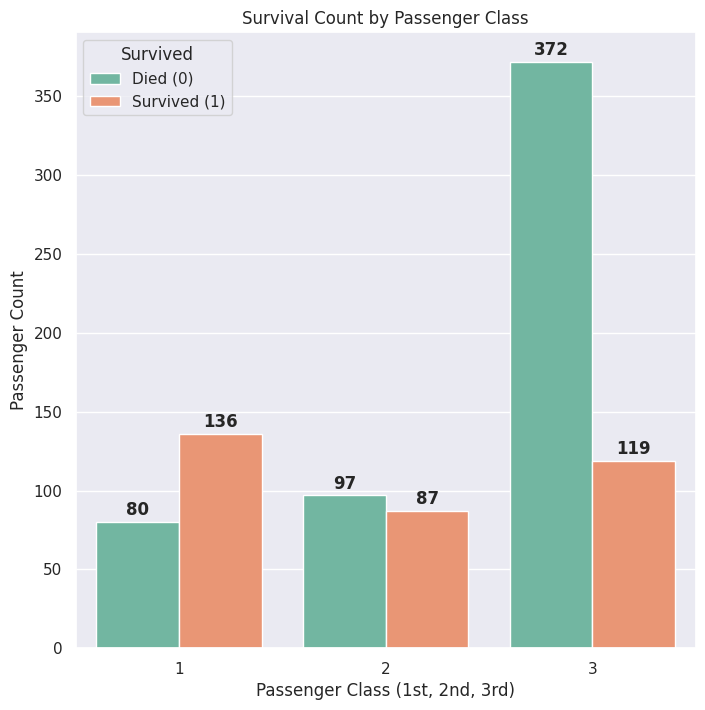

In [26]:
plt.figure(figsize=(8, 8))


ax = sns.countplot(data=df, x='Pclass', hue='Survived', palette='Set2')

plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class (1st, 2nd, 3rd)')
plt.ylabel('Passenger Count')
plt.legend(title='Survived', labels=['Died (0)', 'Survived (1)'])


for container in ax.containers:
    ax.bar_label(container, fontweight='bold', padding=2)

plt.show()

### Insight
* First-class passengers had the highest survival rates, while third-class passengers—especially men—suffered the highest casualties.

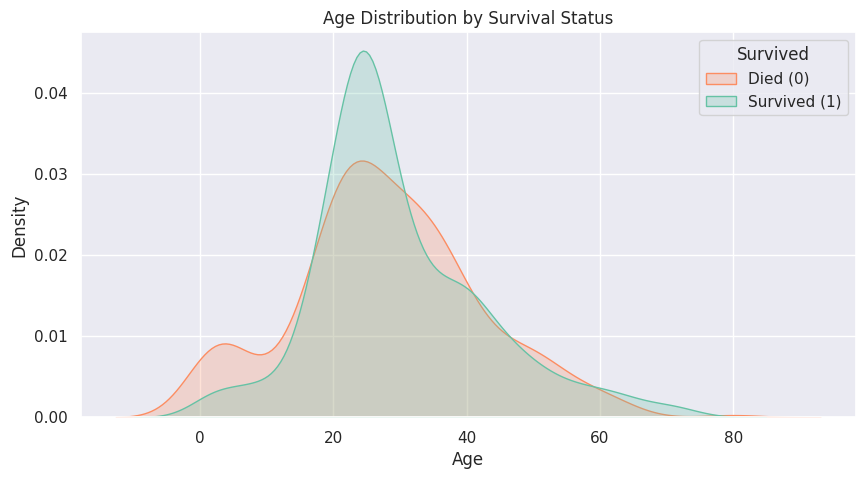

In [27]:


plt.figure(figsize=(10, 5))


sns.kdeplot(data=df, x='Age', hue='Survived', shade=True, palette='Set2', common_norm=False)

plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Survived', labels=['Died (0)', 'Survived (1)'])
plt.show()

###  Key Insight
* Children (aged 0-10) had a much higher chance of survival, while young adults and the elderly faced higher mortality rates.

### Fare Analysis

In [28]:
pd.crosstab(
    pd.qcut(df['Fare'], 4),
    df['Survived']
)

Survived,0,1
Fare,,
"(-0.001, 7.91]",179,44
"(7.91, 14.454]",156,68
"(14.454, 31.0]",121,101
"(31.0, 512.329]",93,129


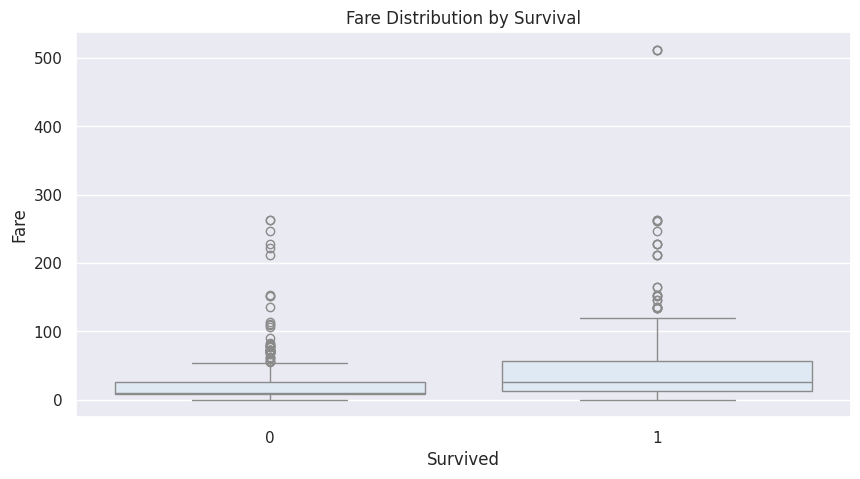

In [29]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='Survived',
    y='Fare'
)

plt.title('Fare Distribution by Survival')
plt.show()

### Key Insight

- Passengers who paid higher fares generally had a better chance of survival.
- Higher fares are strongly associated with first-class tickets.
- This suggests that social class played an important role during evacuation.

### Embarked Analysis

In [30]:
pd.crosstab(
    df['Embarked'],
    df['Survived']
)

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,219


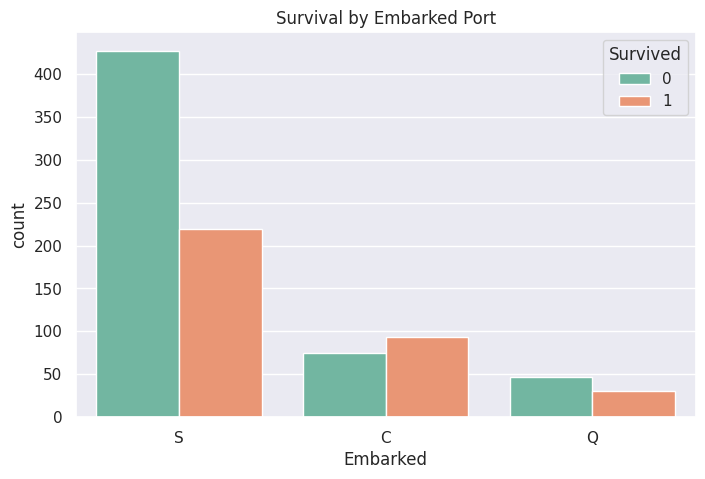

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Embarked',
    hue='Survived',
    palette='Set2'
)

plt.title('Survival by Embarked Port')
plt.show()

### Insight

- Passengers embarking from Cherbourg (C) showed the highest survival rates.
- Southampton (S) had the largest number of passengers and also the largest number of fatalities.
- Port of embarkation may reflect differences in passenger class and ticket fare.

### Correlation Analysis

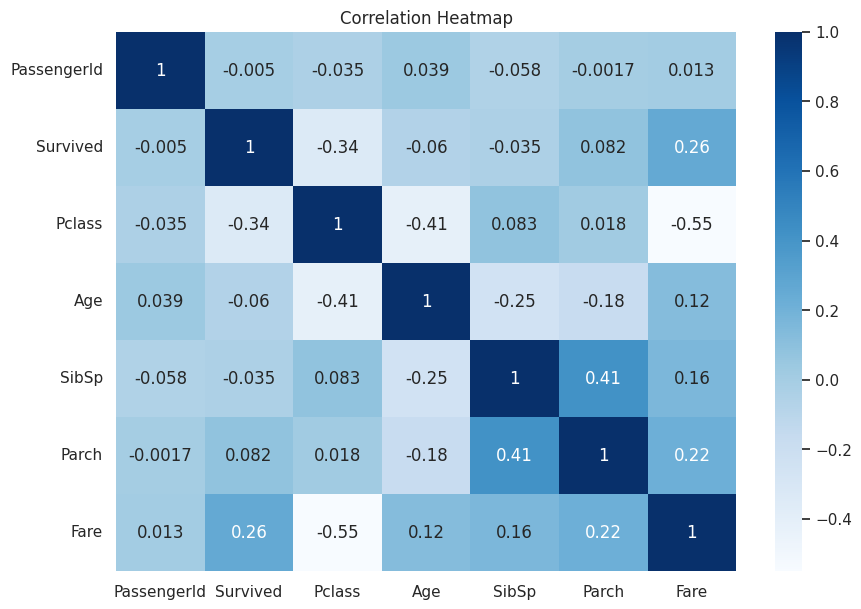

In [32]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Heatmap')
plt.show()

### Key Insight

- Passenger class (Pclass) shows a negative correlation with survival.
- Fare has a positive relationship with survival.
- Age shows only a weak relationship with survival.
- No single variable perfectly explains survival outcomes.


<div style="
    background-color:#1e1e1e;
    padding:40px;
    border-radius:15px;
    border:1px solid #333;
    color:white;
    font-family:Arial;
">

<h1 style="text-align:center;color:#4db8ff;">
Data Analysis Final Summary
</h1>

<h2 style="text-align:center;color:#4db8ff;">
Main Findings
</h2>

<p>
<b>Gender:</b> Female passengers had significantly higher survival rates than males.
</p>

<p>
<b>Passenger Class:</b> First-class passengers were more likely to survive than second- and third-class passengers.
</p>

<p>
<b>Age:</b> Children generally showed better survival outcomes than adults.
</p>

<p>
<b>Fare:</b> Higher ticket fares were associated with higher survival rates.
</p>

<p>
<b>Embarked:</b> Passengers embarking from Cherbourg had the highest survival rates.
</p>

<h2 style="text-align:center;color:#4db8ff;">
Business Insights
</h2>

<p>
The analysis suggests that survival was strongly influenced by social class, gender, age, and economic status.
</p>

<p>
Priority during evacuation appears to have favored women, children, and higher-class passengers.
</p>

<h2 style="text-align:center;color:#4db8ff;">
Project Conclusion
</h2>

<p>
The Titanic disaster demonstrates how demographic and socioeconomic factors can significantly impact outcomes during emergency situations.
</p>

</div>
